# 04d: VAR Model

## Objective
Train VAR (Vector Autoregression) model for weekly bed occupancy forecasting using **true multivariate modeling** with hospital KPIs.

## Data Source
- **Hospital:** ADVENTHEALTH ORLANDO
- **Date Range:** 2020-07-19 to 2024-04-21 (197 weeks)
- **Primary Target:** `bed_occupancy` (weekly average occupied beds)

## Model Design (Updated based on 02_eda.ipynb)
VAR models **multiple related time series jointly**, capturing their interdependencies.

**Endogenous Variables** (based on Granger causality analysis):
- `bed_occupancy` - Primary target variable
- `covid_patient_pct` - COVID burden (Granger-causes bed_occupancy at lags 2,3,5,8)

**Note:** `icu_occupancy_rate` does NOT Granger-cause bed_occupancy per EDA, so it's not used.

## Why True Multivariate VAR?
- COVID burden → affects overall hospital capacity utilization
- Joint modeling captures temporal dynamics between related KPIs
- Rolling forecast with hybrid retraining adapts to changing patterns

## Requirements
- Feature-engineered data from notebook 03 (`features_for_var.csv`)
- KPI data from notebook 01b (`weekly_kpis.csv`)


## Computational Notes

**VAR is a CPU-based statistical model** - GPU acceleration does not apply.

### Model Characteristics:
- **Fast training:** VAR fits in seconds using OLS
- **Lag selection:** AIC criterion for optimal lag order (max 8 weeks)
- **Rolling forecast:** Generates forecasts in 4-week windows with hybrid retraining

### Performance:
- Training time: ~5-10 seconds
- Hybrid retraining: base frequency = 2 weeks or error-triggered



## Install Dependencies (if needed)

If packages are missing, install them here.


In [85]:
# ============================================================================
# PROJECT CONFIGURATION
# ============================================================================
import os

# Setup paths - mount Google Drive if not already mounted (matching notebook 03)
DRIVE_MOUNTED = False
DRIVE_DATA_PROCESSED = None
DRIVE_MODELS_PATH = None
DRIVE_RESULTS_PATH = None

try:
    from google.colab import drive
    # Check if drive is already mounted
    if os.path.exists('/content/drive'):
        DRIVE_MOUNTED = True
        print("✓ Google Drive already mounted")
    else:
        # Mount Google Drive
        print("📁 Mounting Google Drive...")
        drive.mount('/content/drive')
        DRIVE_MOUNTED = True
        print("✓ Google Drive mounted successfully")

    # Set up Google Drive paths
    if DRIVE_MOUNTED:
        DRIVE_ROOT = '/content/drive/MyDrive/hospital_occupancy_forecasting'
        DRIVE_DATA_PROCESSED = os.path.join(DRIVE_ROOT, 'data', 'processed')
        DRIVE_MODELS_PATH = os.path.join(DRIVE_ROOT, 'models')
        DRIVE_RESULTS_PATH = os.path.join(DRIVE_ROOT, 'results', 'visualizations', 'model_development')
        os.makedirs(DRIVE_DATA_PROCESSED, exist_ok=True)
        os.makedirs(DRIVE_MODELS_PATH, exist_ok=True)
        os.makedirs(DRIVE_RESULTS_PATH, exist_ok=True)
        print(f"✓ Google Drive paths configured: {DRIVE_ROOT}")
except ImportError:
    print("ℹ️  Not running in Google Colab (will only check local paths)")
except Exception as e:
    print(f"⚠️  Could not mount Google Drive: {e}")
    print("   Will continue with local Colab paths only")

# Local Colab paths
PROJECT_ROOT = '/content/hospital_occupancy_forecasting'
DATA_DIR = os.path.join(PROJECT_ROOT, 'data')
DATA_RAW = os.path.join(DATA_DIR, 'raw')
DATA_PROCESSED = os.path.join(DATA_DIR, 'processed')
MODELS_PATH = os.path.join(PROJECT_ROOT, 'models')
RESULTS_PATH = os.path.join(PROJECT_ROOT, 'results', 'visualizations', 'model_development')

for path in [DATA_RAW, DATA_PROCESSED, MODELS_PATH, RESULTS_PATH]:
    os.makedirs(path, exist_ok=True)

# Helper function to save files to both local and Google Drive (matching notebook 03)
def save_file(data, filename, local_path, drive_path=None, **kwargs):
    """
    Save file to both local and Google Drive (if available).

    Args:
        data: Data to save (DataFrame, dict, model, etc.)
        filename: Name of the file
        local_path: Local directory path
        drive_path: Google Drive directory path (optional)
        **kwargs: Additional arguments for save methods (e.g., index=False for to_csv)
    """
    # Save to local
    local_file = os.path.join(local_path, filename)
    if isinstance(data, pd.DataFrame):
        data.to_csv(local_file, **kwargs)
    elif isinstance(data, (dict, list)) and filename.endswith('.json'):
        import json
        with open(local_file, 'w') as f:
            json.dump(data, f, **kwargs)
    elif filename.endswith('.pkl'):
        import pickle
        with open(local_file, 'wb') as f:
            pickle.dump(data, f)
    elif hasattr(data, 'save'):
        data.save(local_file)
    else:
        # Fallback: try to write as text
        with open(local_file, 'w') as f:
            f.write(str(data))
    print(f"✓ Saved to local: {local_file}")

    # Save to Google Drive if available
    if drive_path and DRIVE_MOUNTED:
        try:
            drive_file = os.path.join(drive_path, filename)
            if isinstance(data, pd.DataFrame):
                data.to_csv(drive_file, **kwargs)
            elif isinstance(data, (dict, list)) and filename.endswith('.json'):
                import json
                with open(drive_file, 'w') as f:
                    json.dump(data, f, **kwargs)
            elif filename.endswith('.pkl'):
                import pickle
                with open(drive_file, 'wb') as f:
                    pickle.dump(data, f)
            elif hasattr(data, 'save'):
                data.save(drive_file)
            else:
                with open(drive_file, 'w') as f:
                    f.write(str(data))
            print(f"✓ Saved to Google Drive: {drive_file}")
        except Exception as e:
            print(f"⚠️  Could not save to Google Drive: {e}")

# Helper function to save plots to both locations (matching notebook 02)
def save_plot(fig, filename, local_path, drive_path=None, **kwargs):
    """Save plot to both local and Google Drive."""
    local_file = os.path.join(local_path, filename)
    fig.savefig(local_file, **kwargs)
    print(f"✓ Saved plot to local: {local_file}")

    if drive_path and DRIVE_MOUNTED:
        try:
            drive_file = os.path.join(drive_path, filename)
            fig.savefig(drive_file, **kwargs)
            print(f"✓ Saved plot to Google Drive: {drive_file}")
        except Exception as e:
            print(f"⚠️  Could not save plot to Google Drive: {e}")

# Helper function to load file from multiple locations (matching notebook 03)
def load_file(filename, local_path, drive_path=None):
    """
    Load file from local or Google Drive (local priority).

    Returns:
        Loaded data or None if not found
    """
    # Try local first
    local_file = os.path.join(local_path, filename)
    if os.path.exists(local_file):
        if filename.endswith('.csv'):
            return pd.read_csv(local_file, index_col=0, parse_dates=True)
        elif filename.endswith('.pkl'):
            import pickle
            with open(local_file, 'rb') as f:
                return pickle.load(f)
        elif filename.endswith('.json'):
            import json
            with open(local_file, 'r') as f:
                return json.load(f)
        elif filename.endswith('.h5'):
            from tensorflow import keras
            return keras.models.load_model(local_file)

    # Try Google Drive if available
    if drive_path and DRIVE_MOUNTED:
        try:
            drive_file = os.path.join(drive_path, filename)
            if os.path.exists(drive_file):
                if filename.endswith('.csv'):
                    return pd.read_csv(drive_file, index_col=0, parse_dates=True)
                elif filename.endswith('.pkl'):
                    import pickle
                    with open(drive_file, 'rb') as f:
                        return pickle.load(f)
                elif filename.endswith('.json'):
                    import json
                    with open(drive_file, 'r') as f:
                        return json.load(f)
                elif filename.endswith('.h5'):
                    from tensorflow import keras
                    return keras.models.load_model(drive_file)
        except Exception as e:
            print(f"⚠️  Could not load from Google Drive: {e}")

    return None



✓ Google Drive already mounted
✓ Google Drive paths configured: /content/drive/MyDrive/hospital_occupancy_forecasting


In [86]:
try:
    import pmdarima
    print("✓ pmdarima is already installed")
except ImportError:
    print("Installing pmdarima...")
    import subprocess
    import sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "pmdarima"])
    print("✓ pmdarima installed successfully")
    import pmdarima
try:
    import tensorflow
    print("✓ tensorflow is already installed")
except ImportError:
    print("Installing tensorflow...")
    import subprocess
    import sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "tensorflow"])
    print("✓ tensorflow installed successfully")

✓ pmdarima is already installed
✓ tensorflow is already installed


## VAR Model for Weekly Bed Occupancy

This notebook trains a VAR (Vector Autoregression) model for weekly bed occupancy forecasting:
- **Target:** Weekly bed occupancy
- **Related variables:** External features (flu, weather), temporal patterns
- VAR captures the interrelationships between multiple time series


In [87]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
import random
warnings.filterwarnings('ignore')

# Shared evaluation utilities (unified metrics)
METRICS_AVAILABLE = False
try:
    import sys
    if '/content/hospital_occupancy_forecasting/src' not in sys.path:
        sys.path.append('/content/hospital_occupancy_forecasting/src')
    from src.evaluation.metrics import calculate_all_metrics
    METRICS_AVAILABLE = True
except Exception:
    try:
        from evaluation.metrics import calculate_all_metrics
        METRICS_AVAILABLE = True
    except Exception:
        calculate_all_metrics = None
        print("⚠️  Shared metrics utility not available; VAR will use local metric calculations.")

# Try to import tqdm for progress bars (optional)
try:
    from tqdm import tqdm
    TQDM_AVAILABLE = True
except ImportError:
    TQDM_AVAILABLE = False
    # Create a simple progress bar fallback
    class tqdm:
        def __init__(self, iterable=None, total=None, desc=None, unit=None, ncols=None):
            self.iterable = iterable
            self.total = total or (len(iterable) if iterable else None)
            self.desc = desc or ""
            self.unit = unit or "it"
            self.current = 0
            self.last_print = 0

        def __enter__(self):
            if self.desc:
                print(f"{self.desc}...", end="", flush=True)
            return self

        def __exit__(self, *args):
            print()  # New line after completion

        def __iter__(self):
            if self.iterable is None:
                return self
            for item in self.iterable:
                yield item
                self.update(1)

        def update(self, n=1):
            self.current += n
            if self.total:
                pct = (self.current / self.total) * 100
                # Print every 10% or every 100 items
                if pct - self.last_print >= 10 or (self.current % 100 == 0 and self.current > 0):
                    print(f"\r{self.desc}: {self.current}/{self.total} ({pct:.1f}%)", end="", flush=True)
                    self.last_print = pct
                if self.current >= self.total:
                    print()  # New line when complete
            else:
                if self.current % 100 == 0:
                    print(f"\r{self.desc}: {self.current} {self.unit}", end="", flush=True)

        def set_description(self, desc):
            self.desc = desc

# Set random seed for reproducibility
RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

# ============================================================================
# PERFORMANCE OPTIMIZATION CONFIGURATION
# ============================================================================
# Optimized for Google Colab T4 GPU - faster training with minimal accuracy loss

# Configuration
TRAIN_TEST_SPLIT = 0.8

# ARIMA/SARIMA configuration - OPTIMIZED for speed and accuracy
ARIMA_MAX_P = 5  # Increased to allow more AR terms (was 3, now 5 for better pattern capture)
ARIMA_MAX_Q = 5  # Increased to allow more MA terms (was 3, now 5 for better pattern capture)
ARIMA_N_JOBS = -1  # Use all CPU cores
ARIMA_USE_APPROXIMATION = True  # Faster but less precise
ARIMA_MAX_ORDER = 12  # Increased to allow more complex models (was 8, now 12)
ARIMA_MAX_ITER = 15  # Slightly increased iterations for better convergence (was 10)

SARIMA_MAX_P = 2
SARIMA_MAX_Q = 2
SARIMA_MAX_P_SEASONAL = 1
SARIMA_MAX_Q_SEASONAL = 1
SARIMA_MAX_ORDER = 6
SARIMA_N_JOBS = -1
SARIMA_USE_APPROXIMATION = True  # Faster search
SARIMA_MAX_ITER = 10  # Limit iterations for speed

# ============================================================================
# WEEKLY DATA CONFIGURATION (from 03_feature_engineering.ipynb)
# ============================================================================
# Data is weekly bed occupancy (145 weeks after lag_52 dropna)
DATA_FREQUENCY = 'weekly'
WEEKS_PER_YEAR = 52
FORECAST_HORIZON = 4  # Forecast 4 weeks ahead

# ============================================================================
# LOAD CENTRALIZED FEATURE CONFIGURATION (from 03_feature_engineering)
# ============================================================================
# Feature definitions are maintained in ONE place: 03_feature_engineering.ipynb
import json

FEATURE_CONFIG = None
feature_config_paths = [
    os.path.join(DATA_PROCESSED, 'feature_config.json'),
    os.path.join(DRIVE_DATA_PROCESSED, 'feature_config.json') if DRIVE_DATA_PROCESSED else None
]

for config_path in feature_config_paths:
    if config_path and os.path.exists(config_path):
        try:
            with open(config_path, 'r') as f:
                FEATURE_CONFIG = json.load(f)
            print(f"✓ Loaded CENTRALIZED feature config from: {config_path}")
            break
        except Exception as e:
            print(f"⚠️ Error loading {config_path}: {e}")

# VAR configuration - OPTIMIZED for weekly data
# Based on 02_eda.ipynb Granger causality:
#   - covid_patient_pct Granger-causes bed_occupancy (lags 2,3,5,8) ✅
#   - icu_occupancy_rate does NOT Granger-cause bed_occupancy ❌
# VAR HYPERPARAMETERS (hardcoded for consistency - not loaded from config)
# These are tuned for adaptability and variability:
VAR_MAX_LAGS = 4    # Reduced from 8 for faster adaptation (shorter memory)
VAR_IC = 'bic'      # BIC penalizes complexity, selects simpler models
VAR_TREND = 'n'     # No trend for more variability in forecasts

print(f"  VAR hyperparameters: max_lags={VAR_MAX_LAGS}, ic={VAR_IC}, trend={VAR_TREND}")

if FEATURE_CONFIG:
    VAR_CONFIG = FEATURE_CONFIG.get('var', {})
    VAR_ENDOGENOUS_PRIMARY = VAR_CONFIG.get('endogenous_primary', ['bed_occupancy', 'covid_patient_pct'])
    VAR_ENDOGENOUS_FALLBACK = VAR_CONFIG.get('endogenous_fallback', ['bed_occupancy', 'ili', 'temp_min'])
    VAR_EXOGENOUS = VAR_CONFIG.get('exogenous', [])
    print(f"  VAR endogenous primary: {VAR_ENDOGENOUS_PRIMARY}")
    print(f"  VAR endogenous fallback: {VAR_ENDOGENOUS_FALLBACK}")
else:
    # Fallback to hardcoded defaults if config not found
    print("⚠️ Feature config not found, using defaults. Run 03_feature_engineering.ipynb first.")
    VAR_ENDOGENOUS_PRIMARY = ['bed_occupancy', 'covid_patient_pct']  # Based on Granger causality
    VAR_ENDOGENOUS_FALLBACK = ['bed_occupancy', 'ili', 'temp_min']

VAR_WINDOW_SIZE = 4  # 4-week forecast windows
# Hybrid retraining: Fixed intervals + Error-based triggers
VAR_BASE_RETRAIN_FREQUENCY = 2  # Base retraining frequency (every 2 weeks)
VAR_ERROR_THRESHOLD = 1.5  # Retrain early if error > 1.5x historical average
VAR_EARLY_RETRAIN_THRESHOLD = 2  # Minimum weeks between retrains
VAR_SKIP_GRANGER = True  # Skip Granger causality tests (faster)

# VAR variables to model together (will be updated based on data availability)
VAR_ENDOGENOUS_VARS = VAR_ENDOGENOUS_PRIMARY

# LSTM configuration - OPTIMIZED for speed
LSTM_ARCHITECTURE_SEARCH = False  # Skip architecture search (use standard)
LSTM_BATCH_SIZE_SEARCH = False  # Skip batch size search (use 32)
LSTM_BATCH_SIZE = 32  # Fixed batch size
LSTM_MAX_EPOCHS = 30  # Reduced for speed (early stopping will stop earlier)
LSTM_EARLY_STOPPING_PATIENCE = 5  # Stop sooner
LSTM_SEQUENCE_LENGTH = 30  # Keep at 30
LSTM_VALIDATION_SPLIT = 0.2

print("⚡ Performance Optimization: ENABLED (Fast Mode)")
print(f"  ARIMA: max_p={ARIMA_MAX_P}, max_q={ARIMA_MAX_Q}, d=auto (max_d=2), maxiter={ARIMA_MAX_ITER}, approximation={ARIMA_USE_APPROXIMATION}, IC=AIC")
print(f"  SARIMA: max_p={SARIMA_MAX_P}, max_q={SARIMA_MAX_Q}, d=auto (max_d=2), maxiter={SARIMA_MAX_ITER}, approximation={SARIMA_USE_APPROXIMATION}, IC=AIC")
print(f"  VAR: max_lags={VAR_MAX_LAGS}, IC={VAR_IC.upper()}, trend={VAR_TREND}, skip_granger={VAR_SKIP_GRANGER}")
print(f"  LSTM: architecture_search={LSTM_ARCHITECTURE_SEARCH}, batch_size={LSTM_BATCH_SIZE}, max_epochs={LSTM_MAX_EPOCHS}, patience={LSTM_EARLY_STOPPING_PATIENCE}")
print(f"  Retraining: hybrid approach (base={VAR_BASE_RETRAIN_FREQUENCY} days, error threshold={VAR_ERROR_THRESHOLD}x, min interval={VAR_EARLY_RETRAIN_THRESHOLD} days)")
print("  Expected training time: ~1-2 minutes")

# Import ARIMA/SARIMA
from statsmodels.tsa.arima.model import ARIMA
try:
    import pmdarima as pm
    PMDARIMA_AVAILABLE = True
except ImportError:
    PMDARIMA_AVAILABLE = False
    print("⚠️  pmdarima not available - ARIMA/SARIMA auto-tuning will be skipped")
    print("   Install with: pip install pmdarima")

# Import VAR
from statsmodels.tsa.api import VAR

# Import TensorFlow for LSTM
try:
    import tensorflow as tf
    from tensorflow import keras
    from tensorflow.keras.models import Sequential
    from tensorflow.keras.layers import LSTM, Dense, Dropout
    from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
    from sklearn.preprocessing import MinMaxScaler
    TENSORFLOW_AVAILABLE = True
    gpus = tf.config.list_physical_devices('GPU')
    if gpus:
        print(f"🚀 GPU detected: {len(gpus)} GPU(s) available")
        print(f"   GPU: {gpus[0].name}")
        try:
            for gpu in gpus:
                tf.config.experimental.set_memory_growth(gpu, True)
            tf.random.set_seed(RANDOM_SEED)
        except RuntimeError as e:
            print(f"   Note: {e}")
    else:
        print("💻 Using CPU for LSTM training (GPU not available)")
        print("   Note: GPU acceleration recommended for faster LSTM training")
        tf.random.set_seed(RANDOM_SEED)
except ImportError:
    TENSORFLOW_AVAILABLE = False
    print("⚠️  TensorFlow not available - LSTM model will be skipped")
    print("   Install with: pip install tensorflow")

# Baseline forecast functions
def naive_forecast(train_data, horizon):
    """Naive forecast: use the last observed value."""
    if isinstance(train_data, pd.Series):
        last_value = train_data.iloc[-1]
    else:
        last_value = train_data[-1]
    return np.full(horizon, last_value)

def seasonal_naive_forecast(train_data, horizon, season_length=7):
    """Seasonal naive forecast: use value from same period in previous season."""
    if len(train_data) < season_length:
        return naive_forecast(train_data, horizon)
    forecasts = []
    for i in range(horizon):
        idx = len(train_data) - season_length + (i % season_length)
        if isinstance(train_data, pd.Series):
            forecasts.append(train_data.iloc[idx])
        else:
            forecasts.append(train_data[idx])
    return np.array(forecasts)

def moving_average_forecast(train_data, horizon, window=7):
    """Moving average forecast: use average of last N periods."""
    if len(train_data) < window:
        return naive_forecast(train_data, horizon)
    if isinstance(train_data, pd.Series):
        avg = np.mean(train_data.iloc[-window:])
    else:
        avg = np.mean(train_data[-window:])
    return np.full(horizon, avg)

# VAR model functions
def train_var_model(kpi_dataframe, maxlags=4, ic='bic', trend='n'):
    """Train a VAR model on multiple KPIs.

    Args:
        kpi_dataframe: DataFrame with KPI time series
        maxlags: Maximum lag order to consider (default 4 for adaptability)
        ic: Information criterion ('aic', 'bic', 'hqic', 'fpe')
        trend: Trend specification ('c'=constant, 'ct'=constant+trend,
               'ctt'=constant+quadratic, 'n'=none)
    """
    var_model = VAR(kpi_dataframe)
    var_fitted = var_model.fit(maxlags=maxlags, ic=ic, trend=trend, verbose=False)
    return var_fitted

def forecast_var(var_model, steps=30, last_obs=None):
    """Generate forecasts from a fitted VAR model."""
    if last_obs is None:
        last_obs = var_model.y[-var_model.k_ar:]

    # Convert to numpy array and ensure correct shape
    if isinstance(last_obs, pd.DataFrame):
        last_obs = last_obs.values
    last_obs = np.array(last_obs)

    # Ensure we have enough observations (at least k_ar)
    if last_obs.shape[0] < var_model.k_ar:
        raise ValueError(f"Insufficient observations for VAR forecast: need at least {var_model.k_ar}, got {last_obs.shape[0]}")

    # Use only the last k_ar observations
    if last_obs.shape[0] > var_model.k_ar:
        last_obs = last_obs[-var_model.k_ar:]

    # Ensure 2D shape (k_ar, n_vars)
    if last_obs.ndim == 1:
        last_obs = last_obs.reshape(-1, len(var_model.names))

    forecast = var_model.forecast(last_obs, steps=steps)
    return forecast

# Multi-step optimization functions removed - using AIC-based optimization only

print(f"⚡⚡ FAST TRAINING MODE ENABLED (~1-2 minutes)")
print(f"   - Expanded parameter search (max_p={ARIMA_MAX_P}, max_q={ARIMA_MAX_Q})")
print(f"   - Auto-differencing (d determined by ADF test, max_d=2) to find optimal model")
print(f"   - Limited iterations (maxiter={ARIMA_MAX_ITER}) for speed")
print(f"   - Parallel processing: {ARIMA_N_JOBS} jobs")
print(f"   - Approximation methods enabled")
print(f"   - Fast retraining: refit with same order (10x faster than full search)")
print(f"   - Hybrid retraining: base={VAR_BASE_RETRAIN_FREQUENCY} days, error threshold={VAR_ERROR_THRESHOLD}x, min interval={VAR_EARLY_RETRAIN_THRESHOLD} days")
print(f"   - LSTM: max_epochs={LSTM_MAX_EPOCHS}, patience={LSTM_EARLY_STOPPING_PATIENCE}")
print()

⚠️  Shared metrics utility not available; VAR will use local metric calculations.
✓ Loaded CENTRALIZED feature config from: /content/drive/MyDrive/hospital_occupancy_forecasting/data/processed/feature_config.json
  VAR hyperparameters: max_lags=4, ic=bic, trend=n
  VAR endogenous primary: ['bed_occupancy', 'covid_patient_pct']
  VAR endogenous fallback: ['bed_occupancy', 'ili', 'temp_min']
⚡ Performance Optimization: ENABLED (Fast Mode)
  ARIMA: max_p=5, max_q=5, d=auto (max_d=2), maxiter=15, approximation=True, IC=AIC
  SARIMA: max_p=2, max_q=2, d=auto (max_d=2), maxiter=10, approximation=True, IC=AIC
  VAR: max_lags=4, IC=BIC, trend=n, skip_granger=True
  LSTM: architecture_search=False, batch_size=32, max_epochs=30, patience=5
  Retraining: hybrid approach (base=2 days, error threshold=1.5x, min interval=2 days)
  Expected training time: ~1-2 minutes
💻 Using CPU for LSTM training (GPU not available)
   Note: GPU acceleration recommended for faster LSTM training
⚡⚡ FAST TRAINING MODE

## Load Data


In [88]:
# Load weekly bed occupancy with features (from 03_feature_engineering.ipynb)
# Try VAR-specific features first, then general features
print("🔍 Searching for VAR data files...")
data = load_file('features_for_var.csv', DATA_PROCESSED, DRIVE_DATA_PROCESSED)
if data is not None:
    print(f"  ✓ Loaded features_for_var.csv: {len(data)} rows, columns: {list(data.columns)[:5]}...")

if data is None:
    # Fallback: try loading general feature-engineered data
    data = load_file('occupancy_with_features.csv', DATA_PROCESSED, DRIVE_DATA_PROCESSED)
    if data is not None:
        print(f"  ✓ Loaded occupancy_with_features.csv: {len(data)} rows, columns: {list(data.columns)[:5]}...")

if data is None:
    print("  ❌ No data files found! Please run 03_feature_engineering.ipynb first.")
    print(f"     Searched in: {DATA_PROCESSED}")
    if DRIVE_DATA_PROCESSED:
        print(f"     and: {DRIVE_DATA_PROCESSED}")

if data is not None:
    if 'bed_occupancy' in data.columns:
        target_series = data['bed_occupancy']
    else:
        # Try alternative column names
        occupancy_cols = [c for c in data.columns if 'occupancy' in c.lower() or 'bed' in c.lower()]
        if occupancy_cols:
            target_series = data[occupancy_cols[0]]
            print(f"Using column: {occupancy_cols[0]}")
        else:
            target_series = data.iloc[:, 0]
            print(f"Using first column: {data.columns[0]}")
    print(f"Loaded weekly bed occupancy: {len(data)} weeks")
    print(f"Date range: {data.index.min()} to {data.index.max()}")
    print(f"\nTarget variable (bed_occupancy) statistics:")
    print(target_series.describe())

    # Check for VAR-compatible features
    # UPDATED: Check for new hospital KPIs first (preferred), then external features
    print(f"\n📊 VAR ENDOGENOUS VARIABLES CHECK:")
    print(f"   Primary (hospital KPIs): {VAR_ENDOGENOUS_PRIMARY}")
    print(f"   Fallback (external features): {VAR_ENDOGENOUS_FALLBACK}")

    # Check which primary endogenous variables are available
    available_primary = [v for v in VAR_ENDOGENOUS_PRIMARY if v in data.columns]
    missing_primary = [v for v in VAR_ENDOGENOUS_PRIMARY if v not in data.columns]

    print(f"\n   Available primary KPIs: {available_primary}")
    if missing_primary:
        print(f"   Missing primary KPIs: {missing_primary}")

    # Decide which endogenous variables to use
    if len(available_primary) >= 2:  # Need at least 2 variables for VAR
        VAR_ENDOGENOUS_VARS = available_primary
        print(f"\n   ✓ Using PRIMARY endogenous variables: {VAR_ENDOGENOUS_VARS}")
        print(f"     → True multivariate VAR with hospital KPIs")
    else:
        # Fall back to external features
        available_fallback = [v for v in VAR_ENDOGENOUS_FALLBACK if v in data.columns]
        if len(available_fallback) >= 2:
            VAR_ENDOGENOUS_VARS = available_fallback
            print(f"\n   ⚠️ Using FALLBACK endogenous variables: {VAR_ENDOGENOUS_VARS}")
            print(f"     → VAR with external features (re-run 01b for hospital KPIs)")
        else:
            VAR_ENDOGENOUS_VARS = ['bed_occupancy']
            print(f"\n   ❌ Insufficient variables for VAR: {available_fallback}")
            print(f"     → Will use univariate approach")

    # Check data completeness for selected variables
    print(f"\n📊 DATA COMPLETENESS FOR VAR:")
    for var in VAR_ENDOGENOUS_VARS:
        if var in data.columns:
            non_null = data[var].notna().sum()
            pct = 100 * non_null / len(data)
            print(f"   {var}: {non_null}/{len(data)} non-null ({pct:.1f}%)")

    # Also check exogenous features
    var_exog_features = ['ili', 'flu_activity_level', 'temp_avg']
    print(f"\nVAR exogenous features availability:")
    for feat in var_exog_features:
        if feat in data.columns:
            print(f"  {feat}: ✓ Available")
        else:
            print(f"  {feat}: ✗ Not found")
else:
    print(f"File not found: features_for_var.csv")
    print(f"Also tried: occupancy_with_features.csv")
    print("\nPlease run notebooks 01-03 first to create weekly bed occupancy data.")
    target_series = pd.Series(dtype=float)
    data = None

🔍 Searching for VAR data files...
  ✓ Loaded features_for_var.csv: 197 rows, columns: ['bed_occupancy', 'covid_patient_pct', 'quarter_sin', 'quarter_cos', 'day_of_year_sin']...
Loaded weekly bed occupancy: 197 weeks
Date range: 2020-07-19 00:00:00 to 2024-04-21 00:00:00

Target variable (bed_occupancy) statistics:
count     197.000000
mean     2254.367005
std       136.466602
min      1882.000000
25%      2184.700000
50%      2269.400000
75%      2353.400000
max      2510.700000
Name: bed_occupancy, dtype: float64

📊 VAR ENDOGENOUS VARIABLES CHECK:
   Primary (hospital KPIs): ['bed_occupancy', 'covid_patient_pct']
   Fallback (external features): ['bed_occupancy', 'ili', 'temp_min']

   Available primary KPIs: ['bed_occupancy', 'covid_patient_pct']

   ✓ Using PRIMARY endogenous variables: ['bed_occupancy', 'covid_patient_pct']
     → True multivariate VAR with hospital KPIs

📊 DATA COMPLETENESS FOR VAR:
   bed_occupancy: 197/197 non-null (100.0%)
   covid_patient_pct: 151/197 non-null

## Train-Test Split


Train set: 157 weeks (2020-07-19 00:00:00 to 2023-07-16 00:00:00)
Test set: 40 weeks (2023-07-23 00:00:00 to 2024-04-21 00:00:00)
Train/Test split: 157/40 = 80.0%
✓ Saved plot to local: /content/hospital_occupancy_forecasting/results/visualizations/model_development/train_test_split.png
✓ Saved plot to Google Drive: /content/drive/MyDrive/hospital_occupancy_forecasting/results/visualizations/model_development/train_test_split.png


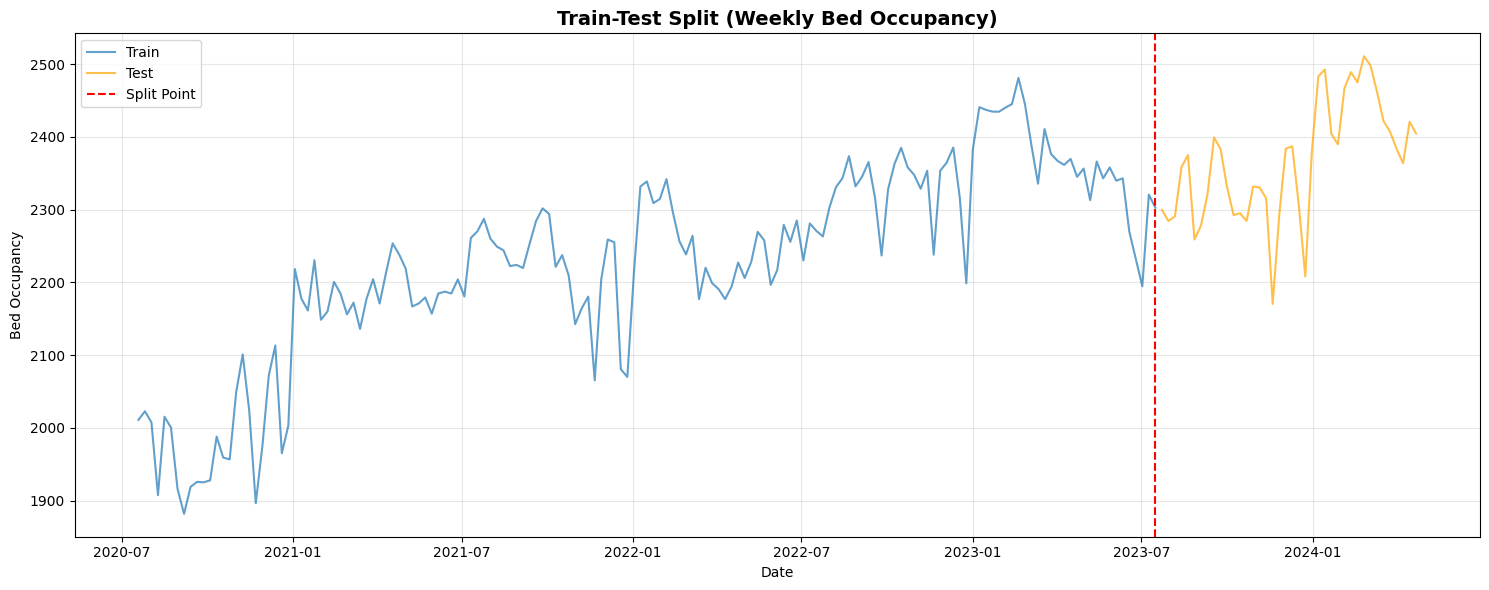

In [89]:
if len(target_series) > 0:
    train_size = int(len(target_series) * TRAIN_TEST_SPLIT)
    train_data = target_series[:train_size]
    test_data = target_series[train_size:]
    print(f"Train set: {len(train_data)} weeks ({train_data.index.min()} to {train_data.index.max()})")
    print(f"Test set: {len(test_data)} weeks ({test_data.index.min()} to {test_data.index.max()})")
    print(f"Train/Test split: {len(train_data)}/{len(test_data)} = {TRAIN_TEST_SPLIT:.1%}")
    plt.figure(figsize=(15, 6))
    plt.plot(train_data.index, train_data.values, label='Train', alpha=0.7, linewidth=1.5)
    plt.plot(test_data.index, test_data.values, label='Test', alpha=0.7, linewidth=1.5, color='orange')
    plt.axvline(x=train_data.index[-1], color='red', linestyle='--', label='Split Point')
    plt.title('Train-Test Split (Weekly Bed Occupancy)', fontsize=14, fontweight='bold')
    plt.xlabel('Date')
    plt.ylabel('Bed Occupancy')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    save_plot(plt.gcf(), 'train_test_split.png', RESULTS_PATH, DRIVE_RESULTS_PATH, dpi=300, bbox_inches='tight')
    plt.show()
else:
    train_data = pd.Series(dtype=float)
    test_data = pd.Series(dtype=float)

## VAR Model - Multi-KPI Forecasting

VAR (Vector Autoregression) forecasts multiple KPIs simultaneously, capturing relationships between operational metrics.



🔍 Searching for KPI data files...
  ✓ Loaded weekly_kpis.csv: 197 weeks, columns: ['bed_occupancy', 'occupancy_rate', 'bed_capacity', 'icu_occupied', 'icu_capacity', 'icu_occupancy_rate', 'covid_inpatients', 'covid_icu', 'covid_patient_pct', 'staffed_beds']
Loaded KPI data: 197 weeks
Available KPIs: ['bed_occupancy', 'occupancy_rate', 'bed_capacity', 'icu_occupied', 'icu_capacity', 'icu_occupancy_rate', 'covid_inpatients', 'covid_icu', 'covid_patient_pct', 'staffed_beds']

Training VAR model with KPIs: ['bed_occupancy', 'covid_patient_pct']
  Train data: 157 weeks (after handling missing values)
  Test data: 40 weeks
  Running Johansen cointegration test on KPI levels...
    Trace statistics:      [25.54  5.13]
    5% critical values:    [15.49  3.84]
    ⇒ Estimated rank (5%): 2
    ✅ Evidence of cointegration; VECM would be appropriate in addition to VAR.
  Checking stationarity of KPIs...
    bed_occupancy: p-value=0.2087 (non-stationary) - applying differencing
    covid_patient_p

  VAR forecasting (days 20-23):  60%|██████    | 6/10 [00:00<00:00, 49.98window/s]

    🔄 Retraining triggered: time-based (base frequency)
    🔄 Retraining triggered: time-based (base frequency)
    🔄 Retraining triggered: time-based (base frequency)
    🔄 Retraining triggered: time-based (base frequency)
    🔄 Retraining triggered: time-based (base frequency)


  VAR forecasting (days 36-39): 100%|██████████| 10/10 [00:00<00:00, 46.11window/s]

    🔄 Retraining triggered: time-based (base frequency)
    🔄 Retraining triggered: time-based (base frequency)
    🔄 Retraining triggered: time-based (base frequency)
    🔄 Retraining triggered: time-based (base frequency)

    ✓ Hybrid retraining: 9 retrains during forecast
    bed_occupancy: window-by-window integration applied (prevents drift)
    bed_occupancy: bounds=[2160.8, 2570.5]
    covid_patient_pct: bounds=[2.6, 2.6]

✓ VAR forecast generated for 40 days using rolling windows

Forecast summary:


       bed_occupancy  covid_patient_pct
count      40.000000       4.000000e+01
mean     2396.360175       2.581528e+00
std       115.962475       3.686825e-15
min      2245.843228       2.581528e+00
25%      2310.080065       2.581528e+00
50%      2351.238767       2.581528e+00
75%      2570.482605       2.581528e+00
max      2570.482605       2.581528e+00
✓ Saved plot to local: /content/hospital_occupancy_forecasting/results/visualizations/model_development/var_forecast.png
✓ Saved plot to Google Drive: /content/drive/MyDrive/hospital_occupancy_forecasting/results/visualizations/model_development/var_forecast.png


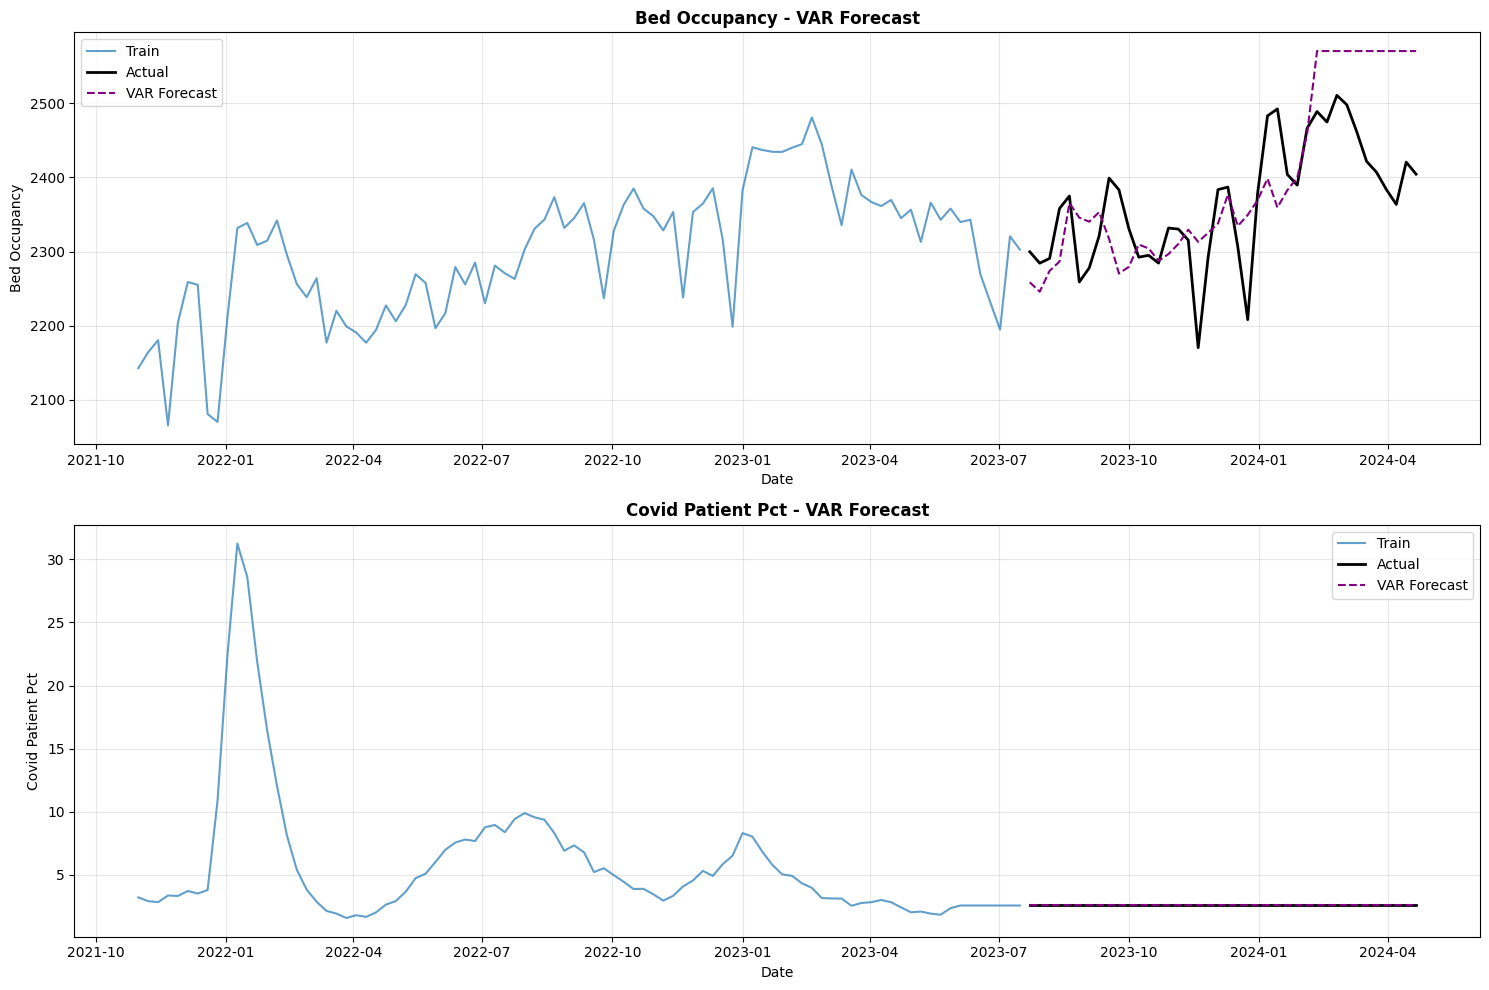

✓ Saved to local: /content/hospital_occupancy_forecasting/models/var_model.pkl
✓ Saved to Google Drive: /content/drive/MyDrive/hospital_occupancy_forecasting/models/var_model.pkl
✓ Saved to local: /content/hospital_occupancy_forecasting/models/var_kpi_scaler.pkl
✓ Saved to Google Drive: /content/drive/MyDrive/hospital_occupancy_forecasting/models/var_kpi_scaler.pkl
✓ Saved to local: /content/hospital_occupancy_forecasting/models/var_differencing_applied.pkl
✓ Saved to Google Drive: /content/drive/MyDrive/hospital_occupancy_forecasting/models/var_differencing_applied.pkl
✓ Saved to local: /content/hospital_occupancy_forecasting/models/var_columns.pkl
✓ Saved to Google Drive: /content/drive/MyDrive/hospital_occupancy_forecasting/models/var_columns.pkl
✓ Saved to local: /content/hospital_occupancy_forecasting/models/var_forecast.csv
✓ Saved to Google Drive: /content/drive/MyDrive/hospital_occupancy_forecasting/models/var_forecast.csv
✓ Saved to local: /content/hospital_occupancy_forecasti

In [90]:
var_model = None
var_forecast = None

# Load KPI data (from multiple locations, matching notebook 03)
# Try daily_kpis.csv first, then weekly_kpis.csv, then create from weekly features
print("\n🔍 Searching for KPI data files...")
kpi_data = load_file('daily_kpis.csv', DATA_PROCESSED, DRIVE_DATA_PROCESSED)
if kpi_data is not None:
    print(f"  ✓ Loaded daily_kpis.csv: {len(kpi_data)} rows, columns: {list(kpi_data.columns)}")

if kpi_data is None:
    # Fallback: try weekly_kpis.csv
    kpi_data = load_file('weekly_kpis.csv', DATA_PROCESSED, DRIVE_DATA_PROCESSED)
    if kpi_data is not None:
        print(f"  ✓ Loaded weekly_kpis.csv: {len(kpi_data)} weeks, columns: {list(kpi_data.columns)}")

if kpi_data is None:
    # Fallback: create KPI dataframe from weekly features data (already loaded in cell 8)
    if data is not None and len(data) > 0:
        print("  Creating KPI dataframe from weekly features data...")
        print(f"    Available columns in data: {list(data.columns)[:10]}...")

        # First check if bed_occupancy exists
        if 'bed_occupancy' not in data.columns:
            # Try to find an occupancy column
            occupancy_cols = [c for c in data.columns if 'occupancy' in c.lower() or 'bed' in c.lower()]
            if occupancy_cols:
                print(f"    ⚠️ 'bed_occupancy' not found, but found: {occupancy_cols}")
                # Rename to bed_occupancy
                data['bed_occupancy'] = data[occupancy_cols[0]]
                print(f"    ✓ Created 'bed_occupancy' from '{occupancy_cols[0]}'")
            else:
                print(f"    ❌ No occupancy column found in data!")

        # Use bed_occupancy and available external features for VAR
        kpi_columns = []
        if 'bed_occupancy' in data.columns:
            kpi_columns.append('bed_occupancy')

        # Add external features that are available
        # NOTE: For VAR endogenous variables, use NON-LAGGED versions because VAR
        # automatically handles lagging internally (it's an autoregressive model).
        # Using pre-lagged variables would introduce an unnecessary extra lag.
        for feat in ['covid_patient_pct', 'ili', 'temp_avg', 'temp_min', 'flu_activity_level']:
            if feat in data.columns and feat not in kpi_columns:
                kpi_columns.append(feat)
                if len(kpi_columns) >= 3:  # Limit to 3 variables for VAR stability
                    break

        if len(kpi_columns) >= 2:  # VAR needs at least 2 variables
            kpi_data = data[kpi_columns].copy()
            print(f"  ✓ Created KPI dataframe with {len(kpi_columns)} variables: {kpi_columns}")
        else:
            print(f"  ❌ Insufficient variables for VAR model (need at least 2, found: {kpi_columns})")
            print(f"     Available in data: {list(data.columns)}")
            kpi_data = None
    else:
        print("  ❌ No data available to create KPI dataframe!")
        print("     Run 03_feature_engineering.ipynb first to create the required data files.")

if kpi_data is not None:
    # Determine if data is daily or weekly based on frequency
    data_freq = 'weekly' if DATA_FREQUENCY == 'weekly' else 'daily'
    freq_unit = 'weeks' if data_freq == 'weekly' else 'days'
    print(f"Loaded KPI data: {len(kpi_data)} {freq_unit}")
    print(f"Available KPIs: {list(kpi_data.columns)}")
    var_columns = []

    # Priority 1: bed_occupancy (required for evaluation)
    occupancy_col = None
    for col_name in ['bed_occupancy', 'bed_occupancy_rate', 'occupancy_rate']:
        if col_name in kpi_data.columns:
            occupancy_col = col_name
            var_columns.append(occupancy_col)
            break

    # Priority 2: External features as additional endogenous variables
    # NOTE: For VAR endogenous variables, use NON-LAGGED versions because VAR
    # automatically handles lagging internally. Using pre-lagged variables would
    # introduce an unnecessary extra lag.
    for feat in ['covid_patient_pct', 'ili', 'temp_avg', 'temp_min', 'flu_activity_level']:
        if feat in kpi_data.columns and len(var_columns) < 3:
            var_columns.append(feat)

    # Priority 3: Traditional KPIs (admissions, discharges, LOS) if available
    if 'admissions' in kpi_data.columns and len(var_columns) < 3:
        var_columns.append('admissions')
    if 'discharges' in kpi_data.columns and len(var_columns) < 3:
        var_columns.append('discharges')
    if 'avg_length_of_stay' in kpi_data.columns and len(var_columns) < 3:
        var_columns.append('avg_length_of_stay')
    elif 'avg_los' in kpi_data.columns and len(var_columns) < 3:
        var_columns.append('avg_los')
    # Verify bed_occupancy is included (required for evaluation)
    if occupancy_col is None or occupancy_col not in var_columns:
        print(f"\n  ⚠️ WARNING: bed_occupancy not found in var_columns: {var_columns}")
        print(f"     kpi_data columns: {list(kpi_data.columns)}")
        print(f"     This will cause evaluation to fail!")

    if len(var_columns) >= 2:
        print(f"\nTraining VAR model with KPIs: {var_columns}")
        var_train_size = int(len(kpi_data) * TRAIN_TEST_SPLIT)

        # Handle missing values with forward-fill instead of dropping rows
        # This prevents empty test data when some KPIs have missing values
        kpi_data_filled = kpi_data[var_columns].ffill().bfill()

        var_train_data = kpi_data_filled[:var_train_size].dropna()
        var_test_data = kpi_data_filled[var_train_size:]

        print(f"  Train data: {len(var_train_data)} weeks (after handling missing values)")
        print(f"  Test data: {len(var_test_data)} weeks")
        if len(var_train_data) >= 30:  # Need sufficient data for VAR
            try:
                # ============================================================
                # IMPROVED VAR TRAINING WITH MULTIPLE OPTIMIZATIONS
                #   + Johansen cointegration testing on levels
                # ============================================================

                # 0. Johansen cointegration test (levels, before differencing)
                try:
                    from statsmodels.tsa.vector_ar.vecm import coint_johansen

                    print("  Running Johansen cointegration test on KPI levels...")
                    j_data = var_train_data[var_columns].dropna()
                    if len(j_data) >= 30 and len(var_columns) >= 2:
                        # Use a small number of lag differences for the test
                        k_ar_diff = min(4, max(1, VAR_MAX_LAGS - 1))
                        j_res = coint_johansen(j_data, det_order=0, k_ar_diff=k_ar_diff)
                        trace_stats = j_res.lr1
                        crit_vals_5 = j_res.cvt[:, 1]  # 5% critical values
                        coint_rank = int((trace_stats > crit_vals_5).sum())

                        print(f"    Trace statistics:      {np.round(trace_stats, 2)}")
                        print(f"    5% critical values:    {np.round(crit_vals_5, 2)}")
                        print(f"    ⇒ Estimated rank (5%): {coint_rank}")
                        if coint_rank > 0:
                            print("    ✅ Evidence of cointegration; VECM would be appropriate in addition to VAR.")
                        else:
                            print("    ℹ️  No strong evidence of cointegration at 5% level (rank=0).")
                    else:
                        print("  Skipping Johansen test (need ≥30 observations and ≥2 variables).")
                except Exception as e:
                    print(f"  ⚠️  Johansen cointegration test failed: {e}")

                # 1. Check stationarity and apply differencing if needed
                print(f"  Checking stationarity of KPIs...")
                from statsmodels.tsa.stattools import adfuller

                var_train_processed = var_train_data.copy()
                differencing_applied = {}

                for kpi in var_columns:
                    # ADF test for stationarity
                    adf_result = adfuller(var_train_processed[kpi].dropna())
                    p_value = adf_result[1]

                    if p_value > 0.05:  # Not stationary
                        print(f"    {kpi}: p-value={p_value:.4f} (non-stationary) - applying differencing")
                        var_train_processed[kpi] = var_train_processed[kpi].diff().dropna()
                        differencing_applied[kpi] = True
                    else:
                        print(f"    {kpi}: p-value={p_value:.4f} (stationary)")
                        differencing_applied[kpi] = False

                # Drop rows with NaN after differencing
                var_train_processed = var_train_processed.dropna()

                if len(var_train_processed) < 30:
                    print("  ⚠️  After differencing, insufficient data. Using original data.")
                    var_train_processed = var_train_data.copy()
                    differencing_applied = {kpi: False for kpi in var_columns}

                # 2. Scale KPIs for better numerical stability
                print(f"  Scaling KPIs for numerical stability...")
                from sklearn.preprocessing import StandardScaler
                kpi_scaler = StandardScaler()
                var_train_scaled = pd.DataFrame(
                    kpi_scaler.fit_transform(var_train_processed),
                    columns=var_columns,
                    index=var_train_processed.index
                )

                # 3. Use configured IC for speed
                print(f"  Using {VAR_IC.upper()} for fast lag selection (single IC)...")
                ic_options = [VAR_IC]
                best_model = None
                best_ic = None
                best_ic_value = np.inf
                ic_results = {}

                for ic in ic_options:
                    try:
                        temp_model = train_var_model(
                            var_train_scaled,
                            maxlags=VAR_MAX_LAGS,
                            ic=ic,
                            trend=VAR_TREND
                        )
                        temp_ic_value = temp_model.info_criteria[ic]
                        ic_results[ic] = {
                            'model': temp_model,
                            'value': temp_ic_value,
                            'lag': temp_model.k_ar
                        }

                        if temp_ic_value < best_ic_value:
                            best_model = temp_model
                            best_ic = ic
                            best_ic_value = temp_ic_value
                            print(f"    {ic.upper()}: lag={temp_model.k_ar}, value={temp_ic_value:.2f} (new best)")
                        else:
                            print(f"    {ic.upper()}: lag={temp_model.k_ar}, value={temp_ic_value:.2f}")
                    except Exception as e:
                        print(f"    {ic.upper()}: Failed ({str(e)[:50]})")
                        continue

                if best_model is None:
                    # Fallback to default BIC
                    print("  Using default BIC as fallback...")
                    best_model = train_var_model(var_train_scaled, maxlags=VAR_MAX_LAGS, ic='bic', trend=VAR_TREND)
                    best_ic = 'bic'
                    best_ic_value = best_model.info_criteria['bic']

                var_model = best_model
                print(f"  ✓ Best model selected using {best_ic.upper()}: lag={var_model.k_ar}, value={best_ic_value:.2f}")

                # 4. Granger Causality Testing (optional but informative, skip in fast mode)
                if not VAR_SKIP_GRANGER:
                    print(f"\n  Testing Granger Causality between KPIs...")
                    try:
                        from statsmodels.tsa.stattools import grangercausalitytests
                        maxlag = min(5, var_model.k_ar)

                        for i, kpi1 in enumerate(var_columns):
                            for j, kpi2 in enumerate(var_columns):
                                if i != j:
                                    try:
                                        test_data = var_train_scaled[[kpi1, kpi2]].dropna()
                                        if len(test_data) > maxlag * 2:
                                            gc_result = grangercausalitytests(test_data, maxlag=maxlag, verbose=False)
                                            # Get p-value for optimal lag
                                            p_values = [gc_result[lag+1][0]['ssr_ftest'][1] for lag in range(maxlag)]
                                            min_p = min(p_values)
                                            if min_p < 0.05:
                                                print(f"    {kpi1} -> {kpi2}: p={min_p:.4f} (significant causality)")
                                            else:
                                                print(f"    {kpi1} -> {kpi2}: p={min_p:.4f} (no significant causality)")
                                    except Exception as e:
                                        pass  # Skip if test fails
                    except Exception as e:
                        print(f"  ⚠️  Granger causality testing failed: {str(e)[:100]}")
                else:
                    print(f"\n  Skipping Granger Causality tests (fast mode - saves ~30 seconds)")

                # 5. Residual diagnostics
                print(f"\n  Performing residual diagnostics...")
                try:
                    residuals = var_model.resid
                    print(f"  Residual statistics for each KPI:")
                    for kpi in var_columns:
                        # Access residuals by column name (DataFrame) or use iloc
                        if isinstance(residuals, pd.DataFrame):
                            kpi_residuals = residuals[kpi].values
                        else:
                            kpi_idx = var_columns.index(kpi)
                            kpi_residuals = residuals[:, kpi_idx]
                        print(f"    {kpi}:")
                        print(f"      Mean: {kpi_residuals.mean():.4f} (should be ~0)")
                        print(f"      Std: {kpi_residuals.std():.4f}")
                        print(f"      Skewness: {pd.Series(kpi_residuals).skew():.4f} (should be ~0)")
                        print(f"      Kurtosis: {pd.Series(kpi_residuals).kurtosis():.4f} (should be ~3)")
                except Exception as e:
                    print(f"  ⚠️  Residual diagnostics failed: {str(e)[:100]}")

                print(f"\n✓ VAR model trained")
                print(f"Selected lag order: {var_model.k_ar}")
                print(f"Information criterion ({best_ic.upper()}): {best_ic_value:.2f}")
                print(f"All IC values:")
                for ic_name, ic_val in var_model.info_criteria.items():
                    print(f"  {ic_name.upper()}: {ic_val:.2f}")
                print("\n" + "="*60)
                print("VAR Model Summary")
                print("="*60)
                print(var_model.summary())
                if len(var_test_data) > 0:
                    # ============================================================
                    # ROLLING WINDOW FORECAST WITH RETRAINING, BOUNDS & SMOOTHING
                    # ============================================================
                    print(f"\nGenerating rolling window VAR forecasts with retraining...")
                    # Use appropriate unit based on data frequency
                    window_unit = 'weeks' if DATA_FREQUENCY == 'weekly' else 'days'
                    retrain_unit = 'weeks' if DATA_FREQUENCY == 'weekly' else 'days'
                    print(f"  Window size: {VAR_WINDOW_SIZE} {window_unit}")
                    print(f"  Hybrid retraining: base={VAR_BASE_RETRAIN_FREQUENCY} {retrain_unit}, error threshold={VAR_ERROR_THRESHOLD}x, min interval={VAR_EARLY_RETRAIN_THRESHOLD} {retrain_unit}")

                    # Calculate bounds for each KPI from training data
                    kpi_bounds = {}
                    for kpi in var_columns:
                        kpi_mean = var_train_data[kpi].mean()
                        kpi_std = var_train_data[kpi].std()
                        kpi_min = var_train_data[kpi].min()
                        kpi_max = var_train_data[kpi].max()

                        # Set reasonable bounds based on KPI type
                        if kpi == 'bed_occupancy':
                            # bed_occupancy is a count - use tight bounds based on historical range
                            # This prevents cumsum integration drift from causing runaway forecasts
                            bounds = (max(0, kpi_min * 0.9), kpi_max + kpi_std)  # ~(1694, 2647)
                        elif 'rate' in kpi or 'pct' in kpi:
                            # Percentage/rate metrics: clip to reasonable range
                            bounds = (0, min(100, kpi_max * 1.5))
                        else:
                            # Other metrics: use historical range with buffer
                            bounds = (max(0, kpi_min * 0.5), kpi_max + 2*kpi_std)

                        kpi_bounds[kpi] = bounds
                        print(f"  {kpi}: bounds=[{bounds[0]:.2f}, {bounds[1]:.2f}]")

                    # Note: Test data preprocessing will be handled during inverse transform
                    # We work with scaled data during forecasting, then transform back

                    # Rolling window forecast with HYBRID RETRAINING (fixed intervals + error-based triggers)
                    WINDOW_SIZE = VAR_WINDOW_SIZE
                    BASE_RETRAIN_FREQ = VAR_BASE_RETRAIN_FREQUENCY if VAR_BASE_RETRAIN_FREQUENCY > 0 else len(var_test_data) + 1  # Disable if 0
                    all_forecasts_list = []
                    # Use scaled training data for last observations (ensure DataFrame format)
                    current_last_obs = var_train_scaled.iloc[-var_model.k_ar:].copy()
                    if not isinstance(current_last_obs, pd.DataFrame):
                        current_last_obs = pd.DataFrame(current_last_obs, columns=var_columns, index=var_train_scaled.index[-var_model.k_ar:])
                    recent_forecasts_by_kpi = {kpi: [] for kpi in var_columns}
                    SMOOTHING_ALPHA = 0.3

                    # Track accumulated data for retraining
                    current_train_kpi = var_train_processed.copy()
                    current_model = var_model
                    days_since_retrain = 0
                    last_retrain_day = 0  # Track when we last retrained
                    retrain_count = 0  # Track total number of retrains

                    # Error tracking for hybrid retraining
                    forecast_errors = []  # Store MAE for each window (for admissions)
                    historical_avg_error = None  # Will be calculated after first few windows
                    min_windows_for_avg = 3  # Need at least 3 windows to calculate average

                    # Forecast in rolling windows with progress indicator
                    num_windows = (len(var_test_data) + WINDOW_SIZE - 1) // WINDOW_SIZE
                    with tqdm(total=num_windows, desc="  VAR forecasting", unit="window") as pbar:
                        for start_idx in range(0, len(var_test_data), WINDOW_SIZE):
                            end_idx = min(start_idx + WINDOW_SIZE, len(var_test_data))
                            horizon = end_idx - start_idx

                            # HYBRID RETRAINING: Check if we need to retrain (time-based OR error-based)
                            should_retrain = False
                            retrain_reason = None

                            # Time-based retraining: Check if base frequency reached
                            time_based_retrain = (BASE_RETRAIN_FREQ > 0 and days_since_retrain >= BASE_RETRAIN_FREQ)

                            # Error-based retraining: Check if error exceeds threshold (only if we have enough history)
                            error_based_retrain = False
                            if (historical_avg_error is not None and
                                len(forecast_errors) > 0 and
                                days_since_retrain >= VAR_EARLY_RETRAIN_THRESHOLD):  # Minimum time between retrains
                                recent_error = forecast_errors[-1]  # Most recent window error
                                if recent_error > historical_avg_error * VAR_ERROR_THRESHOLD:
                                    error_based_retrain = True
                                    retrain_reason = f"error ({recent_error:.2f} > {historical_avg_error * VAR_ERROR_THRESHOLD:.2f})"

                            # Retrain if either condition is met
                            if time_based_retrain:
                                should_retrain = True
                                retrain_reason = "time-based (base frequency)"
                            elif error_based_retrain:
                                should_retrain = True

                            if should_retrain:
                                try:
                                    # Check if we have enough data for retraining
                                    if len(current_train_kpi) >= current_model.k_ar + 10:
                                        # Re-scale accumulated data
                                        current_train_scaled = kpi_scaler.transform(current_train_kpi[var_columns])
                                        current_train_scaled_df = pd.DataFrame(
                                            current_train_scaled,
                                            columns=var_columns,
                                            index=current_train_kpi.index
                                        )

                                        # Fast retraining: refit with same lag order (10x faster)
                                        current_lag = current_model.k_ar
                                        # Fit directly with fixed lag (no search - much faster)
                                        var_temp = VAR(current_train_scaled_df)
                                        current_model = var_temp.fit(maxlags=current_lag, ic=VAR_IC, trend=VAR_TREND, verbose=False)

                                        # Update last observations (ensure we have enough)
                                        if len(current_train_scaled_df) >= current_model.k_ar:
                                            current_last_obs = current_train_scaled_df.iloc[-current_model.k_ar:].copy()
                                        else:
                                            # Fallback: use original training data
                                            current_last_obs = var_train_scaled.iloc[-current_model.k_ar:].copy()
                                            if not isinstance(current_last_obs, pd.DataFrame):
                                                current_last_obs = pd.DataFrame(current_last_obs, columns=var_columns, index=var_train_scaled.index[-current_model.k_ar:])

                                        days_since_retrain = 0
                                        last_retrain_day = start_idx
                                        retrain_count += 1
                                        if retrain_reason:
                                            print(f"    🔄 Retraining triggered: {retrain_reason}")
                                except Exception:
                                    # Silently fallback to previous model on retraining failure
                                    # Ensure last observations are still valid
                                    if len(current_last_obs) < current_model.k_ar:
                                        current_last_obs = var_train_scaled.iloc[-current_model.k_ar:].copy()
                                        if not isinstance(current_last_obs, pd.DataFrame):
                                            current_last_obs = pd.DataFrame(current_last_obs, columns=var_columns, index=var_train_scaled.index[-current_model.k_ar:])

                            # Ensure we have enough observations for forecasting
                            if len(current_last_obs) < current_model.k_ar:
                                current_last_obs = var_train_scaled.iloc[-current_model.k_ar:].copy()
                                if not isinstance(current_last_obs, pd.DataFrame):
                                    current_last_obs = pd.DataFrame(current_last_obs, columns=var_columns, index=var_train_scaled.index[-current_model.k_ar:])

                            # Forecast this window
                            try:
                                window_forecast = forecast_var(
                                    current_model,
                                    steps=horizon,
                                    last_obs=current_last_obs
                                )
                            except Exception:
                                # Fallback: use mean forecast (silent failure)
                                window_forecast = np.tile(
                                    kpi_scaler.inverse_transform(var_train_scaled[-1:].values)[0],
                                    (horizon, 1)
                                )
                                if window_forecast.ndim == 1:
                                    window_forecast = window_forecast.reshape(-1, 1)

                            # Ensure window_forecast is 2D array
                            if window_forecast.ndim == 1:
                                if len(var_columns) == 1:
                                    window_forecast = window_forecast.reshape(-1, 1)
                                else:
                                    window_forecast = window_forecast.reshape(-1, len(var_columns))

                            # Apply smoothing to scaled forecasts (bounds applied after inverse transform)
                            for kpi_idx, kpi in enumerate(var_columns):
                                # Apply smoothing to scaled values
                                if len(recent_forecasts_by_kpi[kpi]) > 0:
                                    first_val = SMOOTHING_ALPHA * window_forecast[0, kpi_idx] + (1 - SMOOTHING_ALPHA) * recent_forecasts_by_kpi[kpi][-1]
                                    window_forecast[0, kpi_idx] = first_val

                                recent_forecasts_by_kpi[kpi].extend(window_forecast[:, kpi_idx].tolist())
                                if len(recent_forecasts_by_kpi[kpi]) > 7:
                                    recent_forecasts_by_kpi[kpi] = recent_forecasts_by_kpi[kpi][-7:]

                            all_forecasts_list.append(window_forecast)

                            # Calculate error for this window (for hybrid retraining) - use admissions
                            if start_idx < len(var_test_data) and 'admissions' in var_columns:
                                try:
                                    admissions_idx = var_columns.index('admissions')
                                    window_actual = var_test_data['admissions'].iloc[start_idx:end_idx].values
                                    window_pred_admissions = window_forecast[:, admissions_idx]

                                    if len(window_actual) == len(window_pred_admissions):
                                        # Calculate MAE for this window (admissions only)
                                        window_mae = np.mean(np.abs(window_actual - window_pred_admissions))
                                        forecast_errors.append(window_mae)

                                        # Update historical average error after minimum windows
                                        if len(forecast_errors) >= min_windows_for_avg:
                                            historical_avg_error = np.mean(forecast_errors)
                                except Exception:
                                    pass  # Skip error calculation if actuals not available

                            # CRITICAL FIX: Update last observations with ACTUAL scaled values, not forecasts
                            # This prevents "forecast from forecast" drift
                            try:
                                # Get actual values for this window and scale them
                                actual_window_vals = var_test_data[var_columns].iloc[start_idx:end_idx].copy()
                                actual_window_scaled = kpi_scaler.transform(actual_window_vals)
                                actual_window_df = pd.DataFrame(
                                    actual_window_scaled,
                                    columns=var_columns,
                                    index=actual_window_vals.index
                                )

                                # Update current_last_obs with actual scaled values
                                if len(actual_window_df) >= current_model.k_ar:
                                    current_last_obs = actual_window_df.iloc[-current_model.k_ar:].copy()
                                else:
                                    # Combine with existing last_obs
                                    needed = current_model.k_ar - len(actual_window_df)
                                    if len(current_last_obs) >= needed:
                                        current_last_obs = pd.concat([
                                            current_last_obs.iloc[-needed:],
                                            actual_window_df
                                        ]).reset_index(drop=True)
                                    else:
                                        # Fallback: use what we have
                                        current_last_obs = pd.concat([
                                            current_last_obs,
                                            actual_window_df
                                        ]).iloc[-current_model.k_ar:].reset_index(drop=True)
                            except Exception:
                                # Fallback: use forecast values if actuals not available
                                if not isinstance(window_forecast, pd.DataFrame):
                                    window_df = pd.DataFrame(window_forecast, columns=var_columns)
                                else:
                                    window_df = window_forecast.copy()
                                if len(window_df) >= current_model.k_ar:
                                    current_last_obs = window_df.iloc[-current_model.k_ar:].copy()

                            # Ensure current_last_obs is scaled (it should be, but double-check)
                            if not isinstance(current_last_obs, pd.DataFrame):
                                current_last_obs = pd.DataFrame(current_last_obs, columns=var_columns)

                            # Accumulate actual values for retraining (if available)
                            if BASE_RETRAIN_FREQ > 0 and start_idx < len(var_test_data):
                                try:
                                    # Get actual values for this window
                                    window_actual = var_test_data[var_columns].iloc[start_idx:end_idx].copy()

                                    # Apply same preprocessing (differencing) if needed
                                    for kpi in var_columns:
                                        if differencing_applied.get(kpi, False):
                                            # Need to integrate (reverse differencing) before adding
                                            # Get last value from training data
                                            last_train_val = current_train_kpi[kpi].iloc[-1] if len(current_train_kpi) > 0 else 0
                                            # Integrate: add differences to last value
                                            window_actual[kpi] = window_actual[kpi].diff().fillna(0) + last_train_val

                                    # Add to training data for next retraining
                                    current_train_kpi = pd.concat([
                                        current_train_kpi,
                                        window_actual
                                    ])

                                    # Limit training data size to prevent memory issues (keep last 2 years)
                                    max_train_size = 730  # ~2 years
                                    if len(current_train_kpi) > max_train_size:
                                        current_train_kpi = current_train_kpi.iloc[-max_train_size:]

                                    days_since_retrain += horizon
                                except Exception as e:
                                    # If we can't accumulate, just increment days
                                    days_since_retrain += horizon

                            pbar.set_description(f"  VAR forecasting (days {start_idx}-{end_idx-1})")
                            pbar.update(1)

                    # Report retraining count
                    if retrain_count > 0:
                        print(f"\n    ✓ Hybrid retraining: {retrain_count} retrains during forecast")
                    else:
                        print(f"\n    ⚠️ No retraining occurred (BASE_RETRAIN_FREQ={BASE_RETRAIN_FREQ}, test windows={num_windows})")

                    # Combine all forecasts
                    forecast_array = np.vstack(all_forecasts_list) if len(all_forecasts_list) > 1 else all_forecasts_list[0]

                    # Inverse transform to get forecasts in original scale
                    forecast_scaled_df = pd.DataFrame(
                        forecast_array,
                        columns=var_columns,
                        index=var_test_data.index[:len(forecast_array)]
                    )

                    # Inverse transform using scaler
                    forecast_original = pd.DataFrame(
                        kpi_scaler.inverse_transform(forecast_scaled_df),
                        columns=var_columns,
                        index=forecast_scaled_df.index
                    )

                    # If differencing was applied, integrate back WINDOW-BY-WINDOW
                    # This prevents cumsum drift by anchoring each window to actual values
                    var_forecast = forecast_original.copy()
                    for kpi in var_columns:
                        if differencing_applied.get(kpi, False):
                            # Window-by-window integration using actual values as anchors
                            integrated_forecast = []

                            for window_start in range(0, len(var_forecast), WINDOW_SIZE):
                                window_end = min(window_start + WINDOW_SIZE, len(var_forecast))
                                window_diffs = var_forecast[kpi].iloc[window_start:window_end].values

                                # Get anchor value: use ACTUAL value just before this window
                                if window_start == 0:
                                    # First window: use last training value
                                    anchor = var_train_data[kpi].iloc[-1]
                                else:
                                    # Subsequent windows: use actual test value from previous window end
                                    try:
                                        anchor = var_test_data[kpi].iloc[window_start - 1]
                                    except:
                                        # Fallback: use last integrated value
                                        anchor = integrated_forecast[-1] if integrated_forecast else var_train_data[kpi].iloc[-1]

                                # Integrate this window from the anchor
                                window_integrated = anchor + np.cumsum(window_diffs)
                                integrated_forecast.extend(window_integrated.tolist())

                            var_forecast[kpi] = integrated_forecast[:len(var_forecast)]
                            print(f"    {kpi}: window-by-window integration applied (prevents drift)")

                    # Apply bounds checking in original scale with TIGHTER bounds
                    for kpi in var_columns:
                        # Use recent actual values for dynamic bounds (last 10 weeks of test data available)
                        recent_actuals = var_test_data[kpi].dropna()
                        if len(recent_actuals) > 0:
                            recent_mean = recent_actuals.mean()
                            recent_std = recent_actuals.std()
                            # Tight bounds: ±2 std from recent mean
                            dynamic_lower = max(kpi_bounds[kpi][0], recent_mean - 2.5 * recent_std)
                            dynamic_upper = min(kpi_bounds[kpi][1], recent_mean + 2.5 * recent_std)
                        else:
                            dynamic_lower, dynamic_upper = kpi_bounds[kpi]

                        var_forecast[kpi] = np.clip(var_forecast[kpi], dynamic_lower, dynamic_upper)
                        print(f"    {kpi}: bounds=[{dynamic_lower:.1f}, {dynamic_upper:.1f}]")

                    var_forecast = var_forecast.clip(lower=0)  # Ensure non-negative
                    print(f"\n✓ VAR forecast generated for {len(var_forecast)} days using rolling windows")
                    print(f"\nForecast summary:")
                    print(var_forecast.describe())
                    fig, axes = plt.subplots(len(var_columns), 1, figsize=(15, 5*len(var_columns)))
                    if len(var_columns) == 1:
                        axes = [axes]
                    for idx, kpi in enumerate(var_columns):
                        axes[idx].plot(
                            var_train_data.index[-90:],
                            var_train_data[kpi].values[-90:],
                            label='Train', alpha=0.7
                        )
                        if kpi in var_test_data.columns:
                            axes[idx].plot(
                                var_test_data.index[:len(var_forecast)],
                                var_test_data[kpi].values[:len(var_forecast)],
                                label='Actual', color='black', linewidth=2
                            )
                        if kpi in var_forecast.columns:
                            axes[idx].plot(
                                var_forecast.index,
                                var_forecast[kpi].values,
                                label='VAR Forecast', linestyle='--', color='purple'
                            )
                        axes[idx].set_title(f'{kpi.replace("_", " ").title()} - VAR Forecast',
                                           fontsize=12, fontweight='bold')
                        axes[idx].set_xlabel('Date')
                        axes[idx].set_ylabel(kpi.replace("_", " ").title())
                        axes[idx].legend()
                        axes[idx].grid(True, alpha=0.3)
                    plt.tight_layout()
                    save_plot(plt.gcf(), 'var_forecast.png', RESULTS_PATH, DRIVE_RESULTS_PATH,
                             dpi=300, bbox_inches='tight')
                    plt.show()

                    # Save model, scaler, and preprocessing info
                    save_file(var_model, 'var_model.pkl', MODELS_PATH, DRIVE_MODELS_PATH)
                    save_file(kpi_scaler, 'var_kpi_scaler.pkl', MODELS_PATH, DRIVE_MODELS_PATH)
                    save_file(differencing_applied, 'var_differencing_applied.pkl', MODELS_PATH, DRIVE_MODELS_PATH)
                    save_file(var_columns, 'var_columns.pkl', MODELS_PATH, DRIVE_MODELS_PATH)

                    # Save VAR forecast for evaluation (especially admissions forecast)
                    save_file(var_forecast, 'var_forecast.csv', MODELS_PATH, DRIVE_MODELS_PATH)

                    # Also save last observations needed for VAR forecasting (scaled)
                    save_file(var_train_scaled[-var_model.k_ar:], 'var_last_observations.csv',
                             MODELS_PATH, DRIVE_MODELS_PATH)
                else:
                    print("Insufficient test data for VAR forecast")
            except Exception as e:
                print(f"VAR model training failed: {e}")
                import traceback
                traceback.print_exc()
        else:
            print(f"Insufficient training data for VAR (need at least 30 observations, got {len(var_train_data)})")
    else:
        print(f"Insufficient KPIs for VAR model (need at least 2, found: {var_columns})")
        print("VAR requires multiple time series. Ensure KPIs were calculated in notebook 02.")
else:
    print("KPI data file not found. VAR model requires multiple KPIs.")
    print("Tried: daily_kpis.csv, weekly_kpis.csv, and creating from weekly features data")
    print("Please ensure that:")
    print("  1. Notebook 01b creates weekly_kpis.csv, OR")
    print("  2. Notebook 03 creates features_for_var.csv with bed_occupancy and external features (ili, temp_avg)")

## Model Evaluation

Calculate basic evaluation metrics to assess VAR model performance (focusing on bed occupancy forecast).


In [91]:
# ============================================================================
# VAR MODEL EVALUATION METRICS (UNIFIED FORMAT)
# ============================================================================

from sklearn.metrics import mean_absolute_error, mean_squared_error

def calculate_var_metrics(y_true, y_pred):
    """Calculate evaluation metrics for VAR model (MAE, RMSE, MAPE, Bias)."""
    y_true = np.array(y_true).flatten()
    y_pred = np.array(y_pred).flatten()

    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))

    # MAPE - handle zeros
    mask = y_true != 0
    if mask.sum() > 0:
        mape = np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100
    else:
        mape = np.nan

    # Bias (mean error)
    bias = np.mean(y_pred - y_true)

    return {
        'MAE': mae,
        'RMSE': rmse,
        'MAPE': mape,
        'Bias': bias,
        'n': len(y_true)
    }

if var_forecast is not None and 'bed_occupancy' in var_forecast.columns:
    # Extract bed_occupancy forecast and actual
    var_forecast_occupancy = var_forecast['bed_occupancy']

    # Get test data for bed_occupancy
    test_occupancy = None
    if 'var_test_data' in globals() and var_test_data is not None and 'bed_occupancy' in var_test_data.columns:
        test_occupancy = var_test_data['bed_occupancy']
    elif 'test_data' in globals() and test_data is not None and len(test_data) > 0:
        test_occupancy = test_data

    # Get train data for bed_occupancy
    train_occupancy = None
    if 'var_train_data' in globals() and var_train_data is not None and 'bed_occupancy' in var_train_data.columns:
        train_occupancy = var_train_data['bed_occupancy']
    elif 'train_data' in globals() and train_data is not None and len(train_data) > 0:
        train_occupancy = train_data

    if test_occupancy is not None:
        # Align forecast with test data
        forecast_aligned = var_forecast_occupancy.reindex(test_occupancy.index)

        # Remove NaN values for metric calculation
        mask = ~(forecast_aligned.isna() | test_occupancy.isna())

        if mask.sum() > 0:
            y_test_true = test_occupancy[mask].values
            y_test_pred = forecast_aligned[mask].values

            # Calculate TEST metrics
            test_metrics = calculate_var_metrics(y_test_true, y_test_pred)

            # Calculate TRAIN metrics (in-sample fitted values)
            train_metrics = None
            if var_model is not None and train_occupancy is not None:
                try:
                    # Get in-sample fitted values from VAR model
                    # VAR fitted values are in scaled space, need to inverse transform
                    fitted_scaled = var_model.fittedvalues

                    # Find bed_occupancy in var_columns
                    if 'bed_occupancy' in var_columns:
                        bed_idx = var_columns.index('bed_occupancy')

                        # Access fitted values by column name (DataFrame) or iloc
                        if isinstance(fitted_scaled, pd.DataFrame):
                            fitted_bed_scaled = fitted_scaled['bed_occupancy'].values
                        else:
                            fitted_bed_scaled = fitted_scaled[:, bed_idx]

                        # Inverse transform using scaler
                        # Create full array for inverse transform
                        fitted_full = np.zeros((len(fitted_bed_scaled), len(var_columns)))
                        fitted_full[:, bed_idx] = fitted_bed_scaled
                        fitted_original = kpi_scaler.inverse_transform(fitted_full)[:, bed_idx]

                        # If differencing was applied, integrate back
                        if differencing_applied.get('bed_occupancy', False):
                            # Get the starting value from original train data
                            start_val = var_train_data['bed_occupancy'].iloc[var_model.k_ar - 1]
                            fitted_original = start_val + np.cumsum(fitted_original)

                        # Align with train data (fitted values start after k_ar lags)
                        train_actual = train_occupancy.iloc[var_model.k_ar:var_model.k_ar + len(fitted_original)]

                        if len(train_actual) > 0 and len(fitted_original) > 0:
                            min_len = min(len(train_actual), len(fitted_original))
                            train_metrics = calculate_var_metrics(
                                train_actual.values[:min_len],
                                fitted_original[:min_len]
                            )
                except Exception as e:
                    print(f"  Note: Could not calculate train metrics: {str(e)[:50]}")
                    train_metrics = None

            # Display results in unified format
            print("="*70)
            print("VAR MODEL EVALUATION")
            print("="*70)
            print(f"\nTrain vs Test metrics (VAR model - bed_occupancy):")
            print(f"{'Set':<12} {'MAE':<10} {'RMSE':<10} {'MAPE (%)':<12} {'Bias':<10} {'n':<8}")
            print("-"*70)

            if train_metrics is not None:
                print(f"{'Train':<12} {train_metrics['MAE']:<10.2f} {train_metrics['RMSE']:<10.2f} {train_metrics['MAPE']:<12.2f} {train_metrics['Bias']:<10.2f} {train_metrics['n']:<8}")
            else:
                print(f"{'Train':<12} {'N/A':<10} {'N/A':<10} {'N/A':<12} {'N/A':<10} {'N/A':<8}")

            print(f"{'Test':<12} {test_metrics['MAE']:<10.2f} {test_metrics['RMSE']:<10.2f} {test_metrics['MAPE']:<12.2f} {test_metrics['Bias']:<10.2f} {test_metrics['n']:<8}")

            # Save results in unified format
            results = {'Test': test_metrics}
            if train_metrics is not None:
                results['Train'] = train_metrics

            results_df = pd.DataFrame(results).T
            results_df = results_df[['MAE', 'RMSE', 'MAPE', 'Bias', 'n']]  # Ensure column order
            save_file(results_df, 'var_evaluation.csv', MODELS_PATH, DRIVE_MODELS_PATH)

            print(f"\n✓ VAR model metrics saved to var_evaluation.csv")
        else:
            print("⚠️  No valid data for evaluation")
    else:
        print("⚠️  Cannot evaluate: 'bed_occupancy' not found in test data")
        print("   Note: Make sure test_data is available from train-test split (cell 10)")
else:
    print("⚠️  Cannot evaluate: VAR forecast not available or 'bed_occupancy' column missing")
    print("   This usually means VAR model training failed. Check that:")
    print("   1. KPI data is available (daily_kpis.csv, weekly_kpis.csv, or weekly features)")
    print("   2. At least 2 KPIs are available for VAR modeling")
    print("   3. Training data has at least 30 observations")



VAR MODEL EVALUATION

Train vs Test metrics (VAR model - bed_occupancy):
Set          MAE        RMSE       MAPE (%)     Bias       n       
----------------------------------------------------------------------
Train        120.31     138.58     5.42         -15.63     153     
Test         70.27      90.62      2.96         30.74      40      
✓ Saved to local: /content/hospital_occupancy_forecasting/models/var_evaluation.csv
✓ Saved to Google Drive: /content/drive/MyDrive/hospital_occupancy_forecasting/models/var_evaluation.csv

✓ VAR model metrics saved to var_evaluation.csv
